In [3]:
import torch
import torch.nn.functional as F
from tqdm.notebook import tqdm

In [34]:
from audio_classification_playground.vox_profile.fluency.wavlm_fluency import WavLMWrapper
from audio_classification_playground.vox_profile.fluency.whisper_fluency import WhisperWrapper

In [5]:
device = torch.device("cuda") if torch.cuda.is_available() else "cpu"
# Load model from Huggingface
model = WavLMWrapper.from_pretrained("tiantiaf/wavlm-large-speech-flow").to(device)
model = model.eval()

config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

In [35]:
device = torch.device("cuda") if torch.cuda.is_available() else "cpu"

model = WhisperWrapper.from_pretrained("tiantiaf/whisper-large-v3-speech-flow").to(device)
model = model.eval()

config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Some weights of WhisperModel were not initialized from the model checkpoint at openai/whisper-large-v3 and are newly initialized because the shapes did not match:
- encoder.embed_positions.weight: found shape torch.Size([1500, 1280]) in the checkpoint and torch.Size([150, 1280]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/6.18G [00:00<?, ?B/s]

In [36]:
import librosa
import torch
import torch.nn.functional as F
SR = 16_000
WINDOW_SEC = 3.0
HOP_SEC = 1.0
BATCH_SIZE = 20
window_samples = int(WINDOW_SEC * SR)   # 56,000
hop_samples = int(HOP_SEC * SR)         # 16,000

In [37]:
audio_path = "/workspace/tmp_data/3d48c229-3505-4a40-b4d2-1e704aa0b8cc.mp3"
audio,_ = librosa.load(audio_path, sr=SR, mono=True)

In [38]:
audio.shape[0]/SR/60

59.03847708333333

In [39]:
# 2. Convert to tensor
audio_t = torch.from_numpy(audio).float()
# 3. Pad so the last partial window isn't silently dropped
remainder = (len(audio_t) - window_samples) % hop_samples
if remainder != 0:
    pad_needed = hop_samples - remainder
    audio_t = F.pad(audio_t, (0, pad_needed))
# 4. Unfold into overlapping windows  →  [N, window_samples]
#    unfold(dim, size, step) returns a view — no copy
windows = audio_t.unfold(0, window_samples, hop_samples)


In [40]:
all_fluency = []
all_dysfluency = []

for i in tqdm(range(0, len(windows), BATCH_SIZE)):
    batch = windows[i : i + BATCH_SIZE].to(device)
    with torch.no_grad():
        fluency_predicted, dysfluency_predicted = model(batch, return_feature=False)
    all_fluency.append(fluency_predicted.cpu())
    all_dysfluency.append(dysfluency_predicted.cpu())

all_fluency = torch.cat(all_fluency)       # [N, 2] logits
all_dysfluency = torch.cat(all_dysfluency) # [N, 5] logits

  0%|          | 0/178 [00:00<?, ?it/s]

In [41]:
fluency_labels = ["fluent", "disfluent"]
disfluency_type_labels = [
    "Block", "Prolongation", "Sound Repetition",
    "Word Repetition", "Interjection",
]

fluency_probs = F.softmax(all_fluency, dim=-1).detach().cpu().numpy()        # [N, 2]
dysfluency_probs = torch.sigmoid(all_dysfluency).detach().cpu().numpy()        # [N, 5]

In [42]:
is_disfluent = fluency_probs[:, 1] > 0.5          # [N]
dysfluency_probs[~is_disfluent] = 0.0             # zero out fluent windows entirely

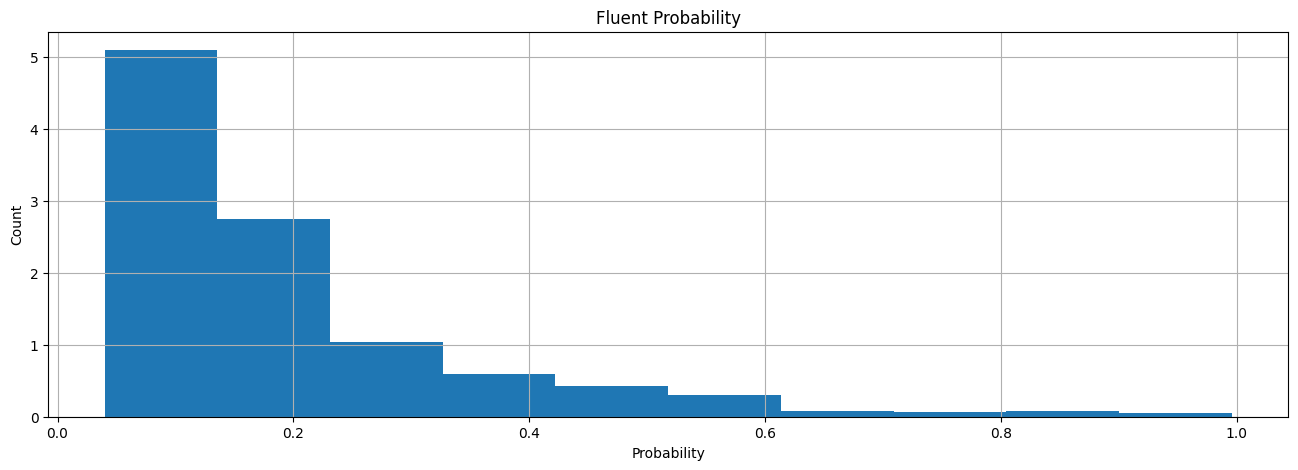

In [43]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(figsize=(16,5))
ax.hist(fluency_probs[:,1],density=True)
ax.set_title("Fluent Probability")
ax.set_xlabel("Probability")
ax.set_ylabel("Count")
ax.grid(True)
plt.show()



In [44]:
import numpy as np

window_centers_sec = np.arange(len(fluency_probs)) * HOP_SEC + WINDOW_SEC / 2
window_centers_min = window_centers_sec / 60

In [45]:
disfluent_frac = is_disfluent.mean().item()
type_hits = (dysfluency_probs > 0.7)
type_fracs = type_hits.mean(axis=0)

print(f"Disfluent: {disfluent_frac:.1%} of windows")
for name, frac in zip(disfluency_type_labels, type_fracs):
    print(f"  {name}: {frac:.1%}")

Disfluent: 6.1% of windows
  Block: 1.1%
  Prolongation: 1.0%
  Sound Repetition: 1.0%
  Word Repetition: 2.1%
  Interjection: 2.8%


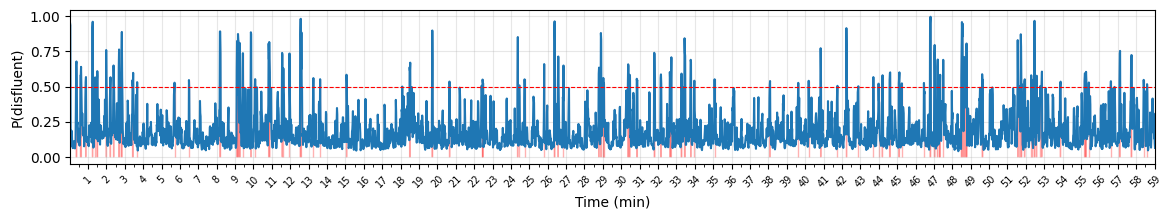

In [46]:
import matplotlib.ticker as ticker

time_min_max = window_centers_min[-1]
minute_ticks = np.arange(0, time_min_max + 1, 1)

fig, ax = plt.subplots(figsize=(14, 2))
ax.plot(window_centers_min, fluency_probs[:, 1])
ax.axhline(0.5, color="red", ls="--", lw=0.8)
ax.fill_between(window_centers_min, fluency_probs[:, 1], 0,
                where=is_disfluent, alpha=0.3, color="red")
ax.set_ylabel("P(disfluent)")
ax.set_xlabel("Time (min)")

ax.set_xticks(minute_ticks)
ax.set_xticklabels([f"{int(t)}" for t in minute_ticks])
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))   # minor every 30s
ax.tick_params(axis="x", which="major", labelsize=7, rotation=45)
ax.tick_params(axis="x", which="minor", length=2)
ax.set_xlim(window_centers_min[0], window_centers_min[-1])
ax.grid(True, which="major", alpha=0.3)

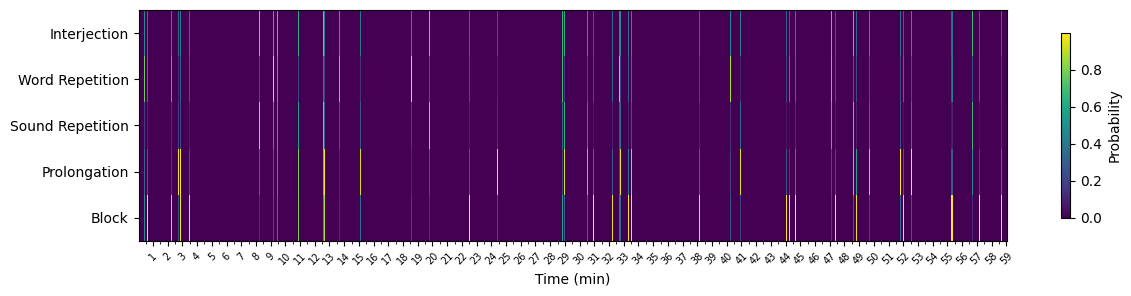

In [47]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(14, 3))
im = ax.imshow(dysfluency_probs.T, aspect="auto", interpolation="nearest",
               extent=[window_centers_min[0], window_centers_min[-1],
                       -0.5, len(disfluency_type_labels) - 0.5])
ax.set_yticks(range(len(disfluency_type_labels)))
ax.set_yticklabels(disfluency_type_labels)
ax.set_xlabel("Time (min)")
fig.colorbar(im, ax=ax, label="Probability", shrink=0.8)

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))      # major every 1 min
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))    # minor every 30s
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
ax.tick_params(axis="x", which="major", labelsize=7, rotation=45)
ax.tick_params(axis="x", which="minor", length=2)